In [58]:
import pickle
import sys

import cv2
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import matplotlib.gridspec as gridspec
from mpl_toolkits.axes_grid1.inset_locator import mark_inset, zoomed_inset_axes
import numpy as np
from PIL import Image

sys.path.append("..")

from solar_irradiance.datamodules.cloud_mask import CloudMask
from solar_irradiance.datamodules.sun_mask import SunMask

### Qualitative Case Study

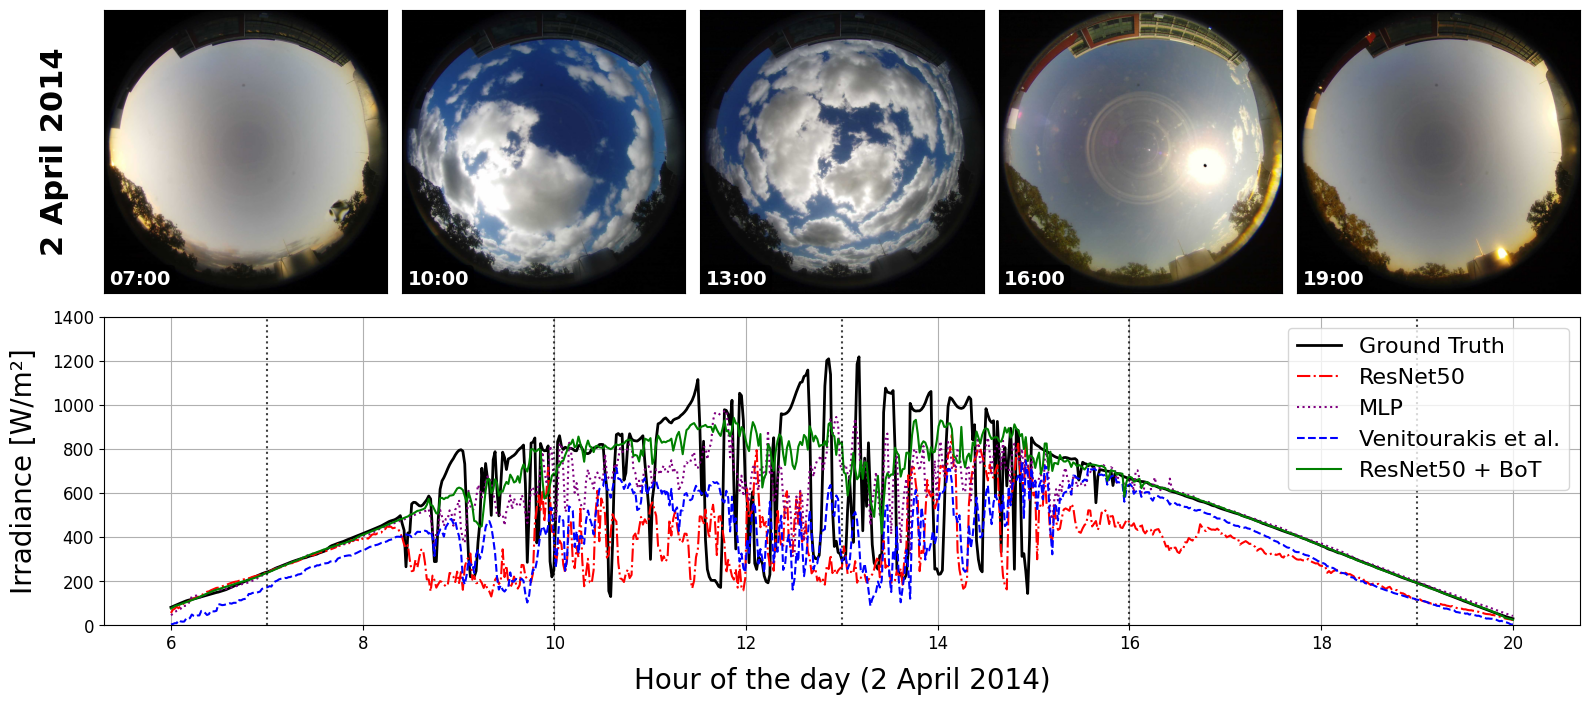

In [113]:
fig = plt.figure(figsize=(16, 7.5))
gs = gridspec.GridSpec(2, 5, figure=fig, height_ratios=[2, 1.75])  # 4 rows, 4 columns total

########## Date 1 ##########
# === 1.1. Load data ===
date = "20140402"
date_word = "2 April 2014"

with open(f"forecasts_{date[6:]}_{date[4:6]}_{date[:4]}.pickle", "rb") as f:
    forecasts = pickle.load(f)

hours = np.linspace(6, 20, len(forecasts["target_irradiances"]))
gt = forecasts["target_irradiances"]
baseline = forecasts["base_resnet50_model_irradiance_forecasts"]
mlp = forecasts["mlp_model_irradiance_forecasts"]
venitourakis = forecasts["venitourakis_model_irradiance_forecasts"]
final = forecasts["bot_irradiance_forecasts"]

# === 1.2. Load images ===
sky_images = [mpimg.imread(f"{date}/{date}_{h}0000.jpg") for h in ["07", "10", "13", "16", "19"]]
sky_hours = [7, 10, 13, 16, 19]

# === 1.3. Add date layout ===
# top row – sky images
for i, (img, h) in enumerate(zip(sky_images, sky_hours)):
    ax = fig.add_subplot(gs[0, i])
    ax.imshow(img)
    if i == 0:
        # add additional space between y-label and the image
        ax.set_ylabel(date_word, fontsize=22, fontweight="bold", labelpad=25)
        ax.yaxis.set_label_position("left")
    ax.set_yticks([])
    ax.set_xticks([])
    ax.text(
        0.02, 0.03, f"{h:02d}:00", color="white", fontsize=14, fontweight="bold",
        transform=ax.transAxes, bbox=dict(facecolor="black", alpha=0.5, boxstyle="round,pad=0.2")
    )

# Bottom row – irradiance plot
ax = fig.add_subplot(gs[1, :])
ax.plot(hours, gt, label="Ground Truth", color="black", linewidth=2)
ax.plot(hours, baseline, label="ResNet50", color="red", linestyle="-.")
ax.plot(hours, mlp, label="MLP", color="purple", linestyle=":")
ax.plot(hours, venitourakis, label="Venitourakis et al.", color="blue", linestyle="--")
ax.plot(hours, final, label="ResNet50 + BoT", color="green", linestyle="-")

for h in sky_hours:
    ax.axvline(h, color="black", linestyle=":", alpha=0.75)

ax.set_xlabel(f"Hour of the day ({date_word})", fontsize=20)
ax.set_ylabel("Irradiance [W/m²]", fontsize=20)
ax.set_ylim(0, 1400)
ax.legend(fontsize=16, loc="upper right")
ax.grid(True)

plt.tight_layout()
plt.savefig(f"Figure_8_qualitative_comparison_{date[6:]}_{date[4:6]}_{date[:4]}.pdf", dpi=300, bbox_inches="tight")

### Image encoders comparison

In [2]:
# !pip install -q fvcore

import timm
import torch
from fvcore.nn import FlopCountAnalysis, parameter_count_table
from calflops import calculate_flops


input_channels = 3

network = timm.create_model(
    "resnet10t",
    pretrained=False,
    num_classes=1,
    in_chans=input_channels,
)
num_features = network.fc.in_features
network.fc = torch.nn.Identity()

num_features += 4  # Add 4 historical irradiances
network_head = torch.nn.Sequential(
    torch.nn.Linear(num_features, 256),
    torch.nn.ReLU(inplace=False),
    torch.nn.Linear(256, 1),
)

# count network parameters
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

network.eval()
network_head.eval()
print(f"Network parameters: {(count_parameters(network) + count_parameters(network_head)) / 1e6:.2f}M")

# FLOPs and Params
# flops = FlopCountAnalysis(network, torch.randn(1, input_channels, 128, 128))
# flops_head = FlopCountAnalysis(network_head, torch.randn(1, num_features))
# print("Total FLOPs:", flops.total() + flops_head.total())
# print("FLOPs (readable):", round((flops.total() + flops_head.total())/ 1e9, 2), "GFLOPs")

flops, macs, params = calculate_flops(
    model=network,
    input_shape=(1, input_channels, 128, 128),
    output_as_string=False,
    output_precision=1, 
    print_results=False,
)

flops_head, macs_head, params_head = calculate_flops(
    model=network_head,
    input_shape=(1, num_features),
    output_as_string=False,
    output_precision=1, 
    print_results=False,
)
print("FLOPs: %sG \nMACs: %sM \nParams: %sM" %(round((flops+flops_head)/1e9, 2), round((macs+macs_head)/1e6, 2), round((params+params_head)/1e6, 2)))

/home/mateusz/miniconda3/envs/irr/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Network parameters: 5.06M
FLOPs: 0.72G 
MACs: 358.25M 
Params: 5.06M


In [3]:
metrics = {
    "ResNet10": {"mae": 35.1672, "rmse": 80.0157, "params": 5.06},
    "ResNet18": {"mae": 33.8755, "rmse": 77.4619, "params": 11.31},
    "ResNet34": {"mae": 34.7898, "rmse": 75.2021, "params": 21.42},
    "ResNet50": {"mae": 35.3474, "rmse": 78.1530, "params": 24.03},
    "SE ResNet50": {"mae": 34.6812, "rmse": 75.7434, "params": 26.56},
    "ResNeXt50 32x4d": {"mae": 34.3521, "rmse": 74.2628, "params": 23.51},
    "RegNetY-64": {"mae": 37.6460, "rmse": 83.3027, "params": 29.62},
    "RegNetZ-D8": {"mae": 35.6716, "rmse": 79.9345, "params": 22.04},
    "MixNet-XL": {"mae": 33.5509, "rmse": 77.2146, "params": 10.75},
    "MobileNetV4-Conv-M": {"mae": 49.8531, "rmse": 91.5613, "params": 8.76},
    "EfficientNetB0": {"mae": 66.2419, "rmse": 92.5984, "params": 4.34},
    "EfficientNetB2": {"mae": 64.4437, "rmse": 91.6032, "params": 8.06},
    "EfficientNetB4": {"mae": 34.6930, "rmse": 82.0725, "params": 18.01},
    "ConvNeXt-T": {"mae": 32.6456, "rmse": 74.9570, "params": 28.02},
    "ConvNeXtV2-T": {"mae": 32.1556, "rmse": 74.6185, "params": 28.06},
    "ConvFormer-S18": {"mae": 33.6365, "rmse": 77.3527, "params": 24.86},
    "EfficientViT-B2": {"mae": 33.6062, "rmse": 77.3957, "params": 22.43},
    "MViTv2-T": {"mae": 32.3656, "rmse": 75.6844, "params": 23.60},
    "MambaOut-T": {"mae": 32.9428, "rmse": 76.5510, "params": 24.83},
}


metrics_bof = {
    "resnet10t": {"mae": 29.9640, "rmse": 70.7071, "params": 5.06},
    "resnet18": {"mae": 29.5178, "rmse": 71.5967, "params": 11.32},
    "resnet34": {"mae": 28.9019, "rmse": 69.5827, "params": 21.43},
    "resnet50": {"mae": 29.2035, "rmse": 69.0372, "params": 24.05},
    "seresnet50": {"mae": 29.6867, "rmse": 70.2639, "params": 26.58},
    "resnext50_32x4d": {"mae": 29.3992, "rmse": 70.4928, "params": 23.52},
    "regnety_064": {"mae": 29.6936, "rmse": 70.6300, "params": 29.62},
    "regnetz_d8": {"mae": 30.3047, "rmse": 71.7214, "params": 22.04},
    "mixnet_xl": {"mae": 30.1310, "rmse": 71.6760, "params": 10.76},
    "mobilenetv4_conv_medium": {"mae": 31.9212, "rmse": 74.2659, "params": 8.76},
    "efficientnet_b0": {"mae": 29.9870, "rmse": 70.8002, "params": 4.34},
    "efficientnet_b2": {"mae": 30.1147, "rmse": 71.7719, "params": 8.06},
    "efficientnet_b4": {"mae": 29.8230, "rmse": 70.7105, "params": 18.01},
    "convnext_tiny": {"mae": 29.6448, "rmse": 71.6660, "params": 28.02},
    "convnextv2_tiny": {"mae": 30.8103, "rmse": 73.2256, "params": 28.07},
    "convformer_s18": {"mae": 29.4714, "rmse": 70.8284, "params": 24.87},
    "efficientvit_b2": {"mae": 29.1208, "rmse": 69.6809, "params": 22.43},
    "mvitv2_tiny": {"mae": 29.6102, "rmse": 70.5444, "params": 23.62},
    "mambaout_tiny": {"mae": 29.8321, "rmse": 71.9664, "params": 24.83},
}

/tmp/ipykernel_292860/909159641.py:179: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


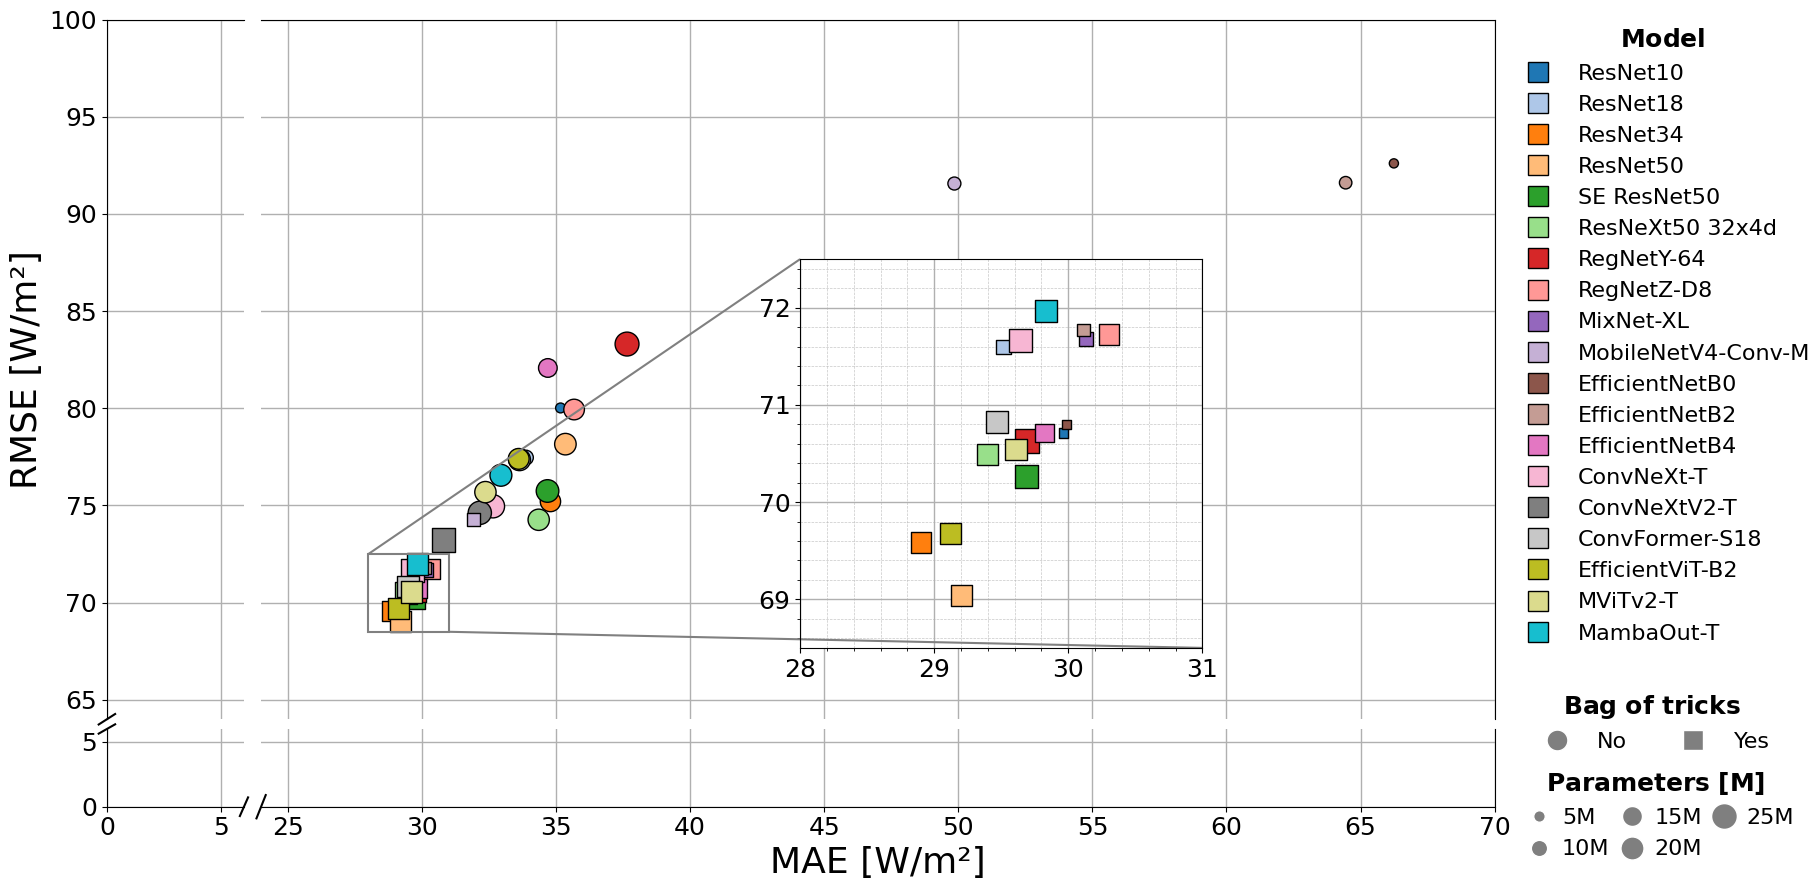

In [ ]:
# colors = ["tab:blue", "tab:orange", "tab:green", "tab:red", "tab:purple", "tab:brown", "tab:pink", "tab:gray"]
colors = [
    "#1f77b4",  # blue
    "#aec7e8",  # light blue
    "#ff7f0e",  # orange
    "#ffbb78",  # light orange
    "#2ca02c",  # green
    "#98df8a",  # light green
    "#d62728",  # red
    "#ff9896",  # light red
    "#9467bd",  # purple
    "#c5b0d5",  # light purple
    "#8c564b",  # brown
    "#c49c94",  # light brown
    "#e377c2",  # pink
    "#f7b6d3",  # light pink
    "#7f7f7f",  # gray
    "#c7c7c7",  # light gray
    "#bcbd22",  # olive
    "#dbdb8d",  # light olive
    "#17becf",  # cyan
    "#9edae5",  # light cyan
]

mae = [metrics[m]["mae"] for m in metrics]
rmse = [metrics[m]["rmse"] for m in metrics]
params = [metrics[m]["params"] * 10 for m in metrics]
models = list(metrics.keys())

fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(
    2, 2, figsize=(18, 9), gridspec_kw={"height_ratios": [4.5, 0.5], "width_ratios": [0.5, 4.5]}
)

# Top row - high y values
ax1.set_xlim(0, 6)
ax1.set_xticks(np.arange(0, 6.1, 5))
ax1.set_ylim(64, 100)
ax2.set_xlim(24, 70)
ax2.set_ylim(64, 100)

# Bottom row - low y values
ax3.set_xlim(0, 6)
ax3.set_ylim(0, 6)
ax4.set_xlim(24, 70)
ax4.set_ylim(0, 6)

ax2.scatter(mae, rmse, s=params, color=colors[: len(mae)], edgecolors="k")

# for i, model in enumerate(models):
#     ax.annotate(model, (mae[i], rmse[i]), fontsize=10, xytext=(5, 5), textcoords="offset points")

mae_bof = [metrics_bof[m]["mae"] for m in metrics_bof]
rmse_bof = [metrics_bof[m]["rmse"] for m in metrics_bof]
params_bof = [metrics_bof[m]["params"] * 10 for m in metrics_bof]
models_bof = list(metrics_bof.keys())

ax2.scatter(mae_bof, rmse_bof, marker="s", s=params_bof, color=colors[: len(mae_bof)], edgecolors="k")

# for i, model_bof in enumerate(models_bof):
#     ax.annotate(model_bof, (mae_bof[i], rmse_bof[i]), fontsize=10, xytext=(5, 5), textcoords="offset points")

# Add legend based on the colors and second based on the markers
handles_colors = [
    plt.Line2D([0], [0], marker="s", color="w", label=model, markerfacecolor=color, markersize=15, markeredgecolor="k")
    for model, color in zip(models, colors, strict=False)
]
handles_size = [
    plt.Line2D([0], [0], marker="o", color="w", label=f"{s//10}M", markerfacecolor="tab:gray", markersize=np.sqrt(s) * 1.175)
    for s in range(50, 251, 50)
]
handles_markers = [
    plt.Line2D([0], [0], marker=marker, color="w", label=label, markerfacecolor="tab:gray", markersize=15)
    for label, marker in [("No", "o"), ("Yes", "s")]
]
legend1 = ax2.legend(
    handles=handles_colors,
    title=r"$\mathbf{Model }$",
    title_fontsize=18,
    fontsize=16,
    bbox_to_anchor=(1.01, 1),
    borderaxespad=0.0,
    # remove the frame around the legend
    frameon=False,
    ncol=1,
)

ax2.add_artist(legend1)

legend2 = ax2.legend(
    handles=handles_markers,
    title=r"$\mathbf{Bag\ of\ tricks}$",
    title_fontsize=18,
    fontsize=16,
    bbox_to_anchor=(1.23, 0.05),
    borderaxespad=0.0,
    # remove the frame around the legend
    frameon=False,
    ncol=2,
)

ax2.add_artist(legend2)

legend3 = ax2.legend(
    handles=handles_size,
    title=r"$\mathbf{Parameters\ [M]}$",
    title_fontsize=18,
    fontsize=16,
    bbox_to_anchor=(1.25, -0.06),
    borderaxespad=0.0,
    # remove the frame around the legend
    frameon=False,
    columnspacing=0.01,
    handletextpad=0.01,
    ncol=3,
)

# Remove spines between plots
ax1.spines["bottom"].set_visible(False)
ax1.spines["right"].set_visible(False)
ax2.spines["bottom"].set_visible(False)
ax2.spines["left"].set_visible(False)
ax3.spines["top"].set_visible(False)
ax3.spines["right"].set_visible(False)
ax4.spines["top"].set_visible(False)
ax4.spines["left"].set_visible(False)

# Remove x-axis labels and ticks from top plots
ax1.tick_params(labelbottom=False, bottom=False)
ax2.tick_params(labelbottom=False, bottom=False)

# Remove y-axis labels and ticks from right plots
ax2.tick_params(labelleft=False, left=False)
ax4.tick_params(labelleft=False, left=False)

# Add break marks
d = 0.015  # size of diagonal lines

# top-left
kwargs = dict(transform=ax1.transAxes, color="k", clip_on=False, linewidth=1.5)
ax1.plot((-4 * d, +4 * d), (-0.5 * d, +0.5 * d), **kwargs)

# bottom-left
kwargs.update(transform=ax3.transAxes)
ax3.plot((1 - 2 * d, 1 + 2 * d), (-8 * d, +8 * d), **kwargs)
ax3.plot((-4 * d, +4 * d), (1 - 4 * d, 1 + 4 * d), **kwargs)

# bottom-right
kwargs.update(transform=ax4.transAxes)
ax4.plot((-0.25 * d, +0.25 * d), (-10 * d, +10 * d), **kwargs)

# https://gist.github.com/nicoguaro/b91c4bf7a8815676bfb9
axins = zoomed_inset_axes(ax2, 5, loc="lower center", bbox_to_anchor=(0.6, 0.1), bbox_transform=ax2.transAxes, borderpad=0.1)
axins.scatter(mae_bof, rmse_bof, marker="s", s=params_bof, color=colors[: len(mae_bof)], alpha=1, edgecolors="k")
axins.set_xlim(28, 31)  # Limit the region for zoom
axins.set_ylim(68.5, 72.5)
axins.set_xticks(np.arange(28, 31.1, 1))
axins.minorticks_on()
axins.set_yticks(np.arange(69, 72.1, 1))
axins.tick_params(axis="both", which="major", labelsize=18)
# axins.set_xlabel("MAE [W/m²]", fontsize=18)
# axins.set_ylabel("RMSE [W/m²]", fontsize=18)
# Set opaque background
axins.set_facecolor("white")  # Or any color you prefer
axins.patch.set_alpha(1.0)  # Ensure full opacity

mark_inset(ax2, axins, loc1=2, loc2=4, fc="none", ec="0.5", lw=1.5)

ax1.tick_params(axis="y", which="major", labelsize=18)
ax3.tick_params(axis="both", which="major", labelsize=18)
ax4.tick_params(axis="x", which="major", labelsize=18)
ax2.set_xticks(np.arange(25, 71, 5))
ax4.set_xticks(np.arange(25, 71, 5))
ax4.set_xlabel("MAE [W/m²]", fontsize=26)
ax1.set_ylabel("RMSE [W/m²]", fontsize=26)
for _ax in [ax1, ax2, ax3, ax4, axins]:
    _ax.grid(True, which="major", linestyle="-", linewidth=1.0, alpha=1.0)
    _ax.grid(True, which="minor", linestyle="--", linewidth=0.5, alpha=0.7)
    _ax.set_axisbelow(True)
plt.tight_layout()
plt.subplots_adjust(wspace=0.025, hspace=0.025)
# plt.show()
# plt.savefig("Figure_7_model_comparison.pdf", bbox_inches="tight", dpi=300, transparent=False)

### RGB channels

In [2]:
img = np.asarray(Image.open("./images/images/20140509_200700.jpg"))

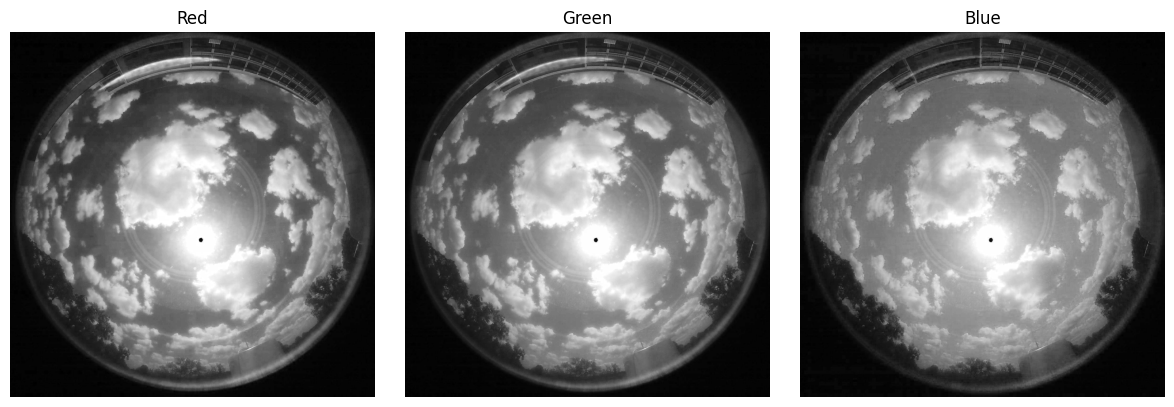

In [3]:
fig, ax = plt.subplots(1, 3, figsize=(12, 4))

for idx, color in enumerate(["Red", "Green", "Blue"]):
    ax[idx].imshow(img[..., idx], cmap="gray")
    ax[idx].axis("off")
    ax[idx].set_title(color)

plt.tight_layout()

### Sun Mask

In [4]:
LATITUDE = 38.642
LONGITUDE = -121.148
CAMERA_ORIENTATION_COMPENSATION = 165
FOCAL_LENGTH = 0.48

sun_mask_gen = SunMask(
    latitude=LATITUDE,
    longitude=LONGITUDE,
    camera_orientation_compensation=CAMERA_ORIENTATION_COMPENSATION,
    focal_length=FOCAL_LENGTH,
)

In [5]:
sun_mask = sun_mask_gen((1536, 1536), timestamp="20140509_200700")

(-0.5, 1535.5, 1535.5, -0.5)

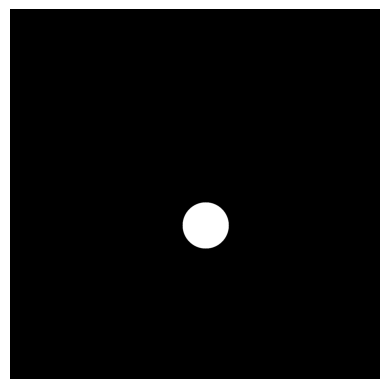

In [6]:
plt.imshow(sun_mask, cmap="gray")
plt.axis("off")

### Cloud Channel

In [7]:
cm_mask_gen = CloudMask(shape=(1536, 1536), method="normalized_blue_red_ratio")

In [8]:
cm_mask = cm_mask_gen(img)

(-0.5, 1535.5, 1535.5, -0.5)

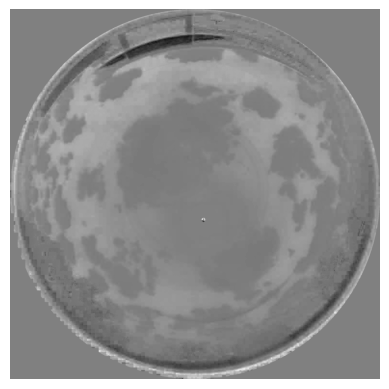

In [9]:
plt.imshow(cm_mask, cmap="gray", vmin=0, vmax=1)
plt.axis("off")

### Optical Flow

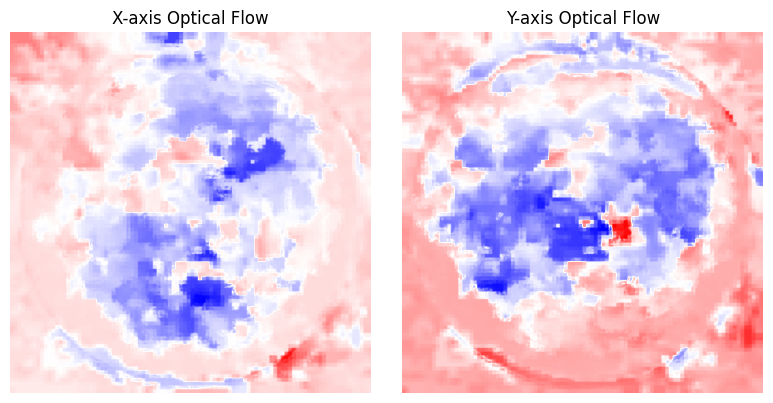

In [10]:
dis_of = cv2.DISOpticalFlow_create(preset=cv2.DISOPTICAL_FLOW_PRESET_ULTRAFAST)
flow = None

imgs = [
    "./images/images/20140509_195200.jpg",
    "./images/images/20140509_195700.jpg",
    "./images/images/20140509_200200.jpg",
    "./images/images/20140509_200700.jpg",
]

for idx in range(1, 4):
    img1_grey = np.asarray(Image.open(imgs[idx - 1]).convert("L"))
    img2_grey = np.asarray(Image.open(imgs[idx]).convert("L"))

    flow = dis_of.calc(img1_grey, img2_grey, flow)

fig, ax = plt.subplots(1, 2, figsize=(8, 4))

for idx, label in enumerate(["X-axis Optical Flow", "Y-axis Optical Flow"]):
    ax[idx].imshow(flow[..., idx], cmap="bwr")
    ax[idx].axis("off")
    ax[idx].set_title(label)

plt.tight_layout()

# Raspberry Pi evaluation

In [18]:
rpi_4B_inference = [0.0934, 0.1273, 0.2608, 0.4450, 1.0586]
rpi_4B_inference_std = [0.0043, 0.0043, 0.0022, 0.0076, 0.0185]
rpi_5_inference = [0.0330, 0.0504, 0.1021, 0.1863, 0.4554]
rpi_5_inference_std = [0.0018, 0.0045, 0.0093, 0.0087, 0.0059]

rpi_4B_preprocessing = [0.0212, 0.0222, 0.0257, 0.0434, 0.0788]
rpi_4B_preprocessing_std = [0.0021, 0.0010, 0.0060, 0.0085, 0.0078]
rpi_5_preprocessing = [0.0053, 0.0079, 0.0136, 0.0238, 0.0475]
rpi_5_preprocessing_std = [0.0003, 0.0011, 0.0016, 0.0023, 0.0034]

rpi_4B_sun_mask = [0.0148, 0.0150, 0.0156, 0.0172, 0.0216]
rpi_4B_sun_mask_std = [0.0003, 0.0002, 0.0002, 0.0006, 0.0009]
rpi_5_sun_mask = [0.0048, 0.0061, 0.0070, 0.0079, 0.0108]
rpi_5_sun_mask_std = [0.0004, 0.0011, 0.0010, 0.0008, 0.0007]

rpi_4B_irradiance_channel = [0.0001, 0.0001, 0.0002, 0.0009, 0.0024]
rpi_4B_irradiance_channel_std = [0.0000, 0.0000, 0.0000, 0.0001, 0.0001]
rpi_5_irradiance_channel = [0.0000, 0.0001, 0.0001, 0.0002, 0.0008]
rpi_5_irradiance_channel_std = [0.0000, 0.0000, 0.0000, 0.0001, 0.0001]

rpi_4B_cloud_channel = [0.0008, 0.0014, 0.0039, 0.0081, 0.0200]
rpi_4B_cloud_channel_std = [0.0000, 0.0001, 0.0002, 0.0005, 0.0009]
rpi_5_cloud_channel = [0.0003, 0.0007, 0.0016, 0.0035, 0.0112]
rpi_5_cloud_channel_std = [0.0000, 0.0001, 0.0002, 0.0004, 0.0005]

rpi_4B_optical_flow = [0.0070, 0.0106, 0.0228, 0.0360, 0.0809]
rpi_4B_optical_flow_std = [0.0028, 0.0006, 0.0012, 0.0022, 0.0041]
rpi_5_optical_flow = [0.0034, 0.0053, 0.0128, 0.0209, 0.0546]
rpi_5_optical_flow_std = [0.0032, 0.0008, 0.0013, 0.0015, 0.0027]

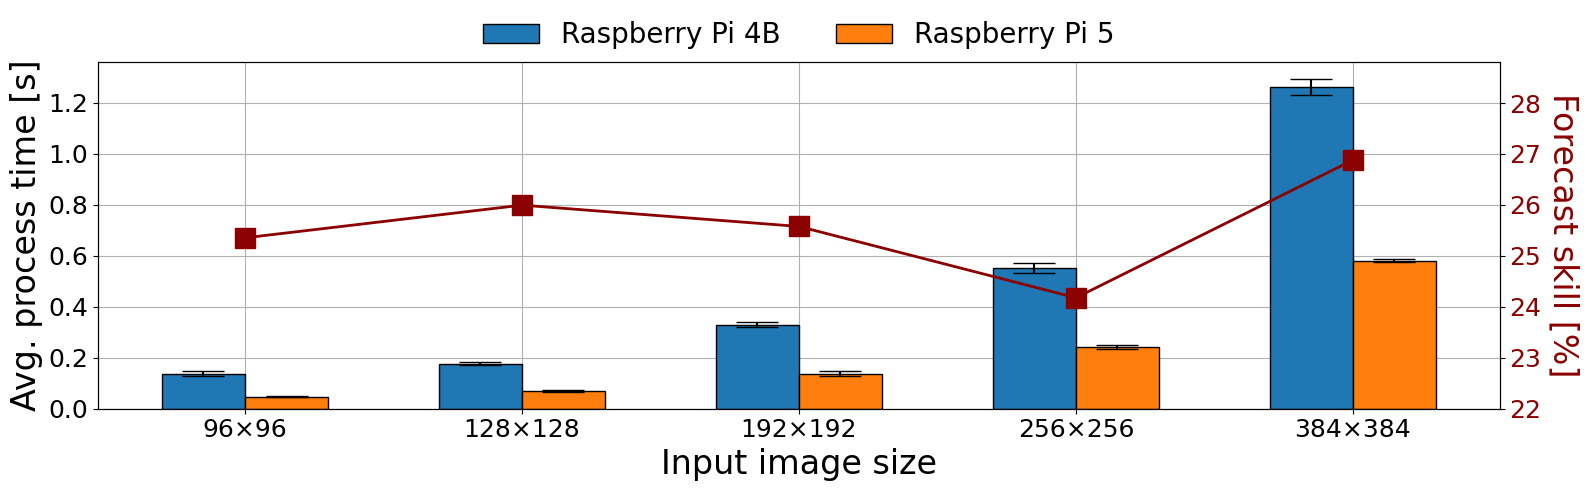

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(16, 5))

X = ["96×96", "128×128", "192×192", "256×256", "384×384"]

X_axis = np.arange(len(X))
Y_axis = np.round(np.arange(0, 1.4, 0.2), 1)

width = 0.3
rpi_4B_process = (
    np.array(rpi_4B_inference)
    + np.array(rpi_4B_preprocessing)
    + np.array(rpi_4B_sun_mask)
    + np.array(rpi_4B_irradiance_channel)
    + np.array(rpi_4B_cloud_channel)
    + np.array(rpi_4B_optical_flow)
)
yerr = (
    np.array(rpi_4B_inference_std)
    + np.array(rpi_4B_preprocessing_std)
    + np.array(rpi_4B_sun_mask_std)
    + np.array(rpi_4B_irradiance_channel_std)
    + np.array(rpi_4B_cloud_channel_std)
    + np.array(rpi_4B_optical_flow_std)
)
ax.bar(X_axis - width / 2, rpi_4B_process, width, label="Raspberry Pi 4B", edgecolor="black")
ax.errorbar(X_axis - width / 2, rpi_4B_process, yerr=yerr, fmt="none", ecolor="black", capsize=15)

rpi_5_process = (
    np.array(rpi_5_inference)
    + np.array(rpi_5_preprocessing)
    + np.array(rpi_5_sun_mask)
    + np.array(rpi_5_irradiance_channel)
    + np.array(rpi_5_cloud_channel)
    + np.array(rpi_5_optical_flow)
)
yerr = (
    np.array(rpi_5_inference_std)
    + np.array(rpi_5_preprocessing_std)
    + np.array(rpi_5_sun_mask_std)
    + np.array(rpi_5_irradiance_channel_std)
    + np.array(rpi_5_cloud_channel_std)
    + np.array(rpi_5_optical_flow_std)
)
ax.bar(X_axis + width / 2, rpi_5_process, width, label="Raspberry Pi 5", edgecolor="black")
ax.errorbar(X_axis + width / 2, rpi_5_process, yerr=rpi_5_inference_std, fmt="none", ecolor="black", capsize=15)

ax.set_xticks(X_axis, X, fontsize=18)
ax.set_yticks(Y_axis, Y_axis, fontsize=18)
ax.set_xlabel("Input image size", fontsize=24)
ax.set_ylabel("Avg. process time [s]", fontsize=24)
ax.grid(True)
ax.set_axisbelow(True)
# plot legend above the plot
plt.legend(loc="upper center", bbox_to_anchor=(0.5, 1.15), ncol=2, fontsize=20, borderaxespad=0.0, frameon=False,)
# plt.legend(fontsize=20)
plt.tight_layout()
# plt.show()

# add 2nd y-axis on the right side with range from 0 to 50
forecast_skill = np.array([25.45, 26.11, 25.68, 24.24, 27.02])
ax2 = ax.twinx()
ax2.set_ylim(22, 29)

# plot forecast_skill values on the right y-axis
ax2.plot(X_axis, forecast_skill, color="darkred", marker="s", label="Forecast skill [%]", linewidth=2, markersize=15)

ax2.set_yticks([22, 23.03, 24.06, 25.09, 26.12, 27.15, 28.17], np.arange(22, 29, 1).astype(int), fontsize=18, color="darkred")
# rotate the y-axis label by 180 degrees
ax2.set_ylabel("Forecast skill [%]", fontsize=24, rotation=270, va="bottom", color="darkred")
# ax2.grid(True)  # Disable grid for the second y-axis

plt.tight_layout()
plt.savefig("figure_8_process_times.pdf")

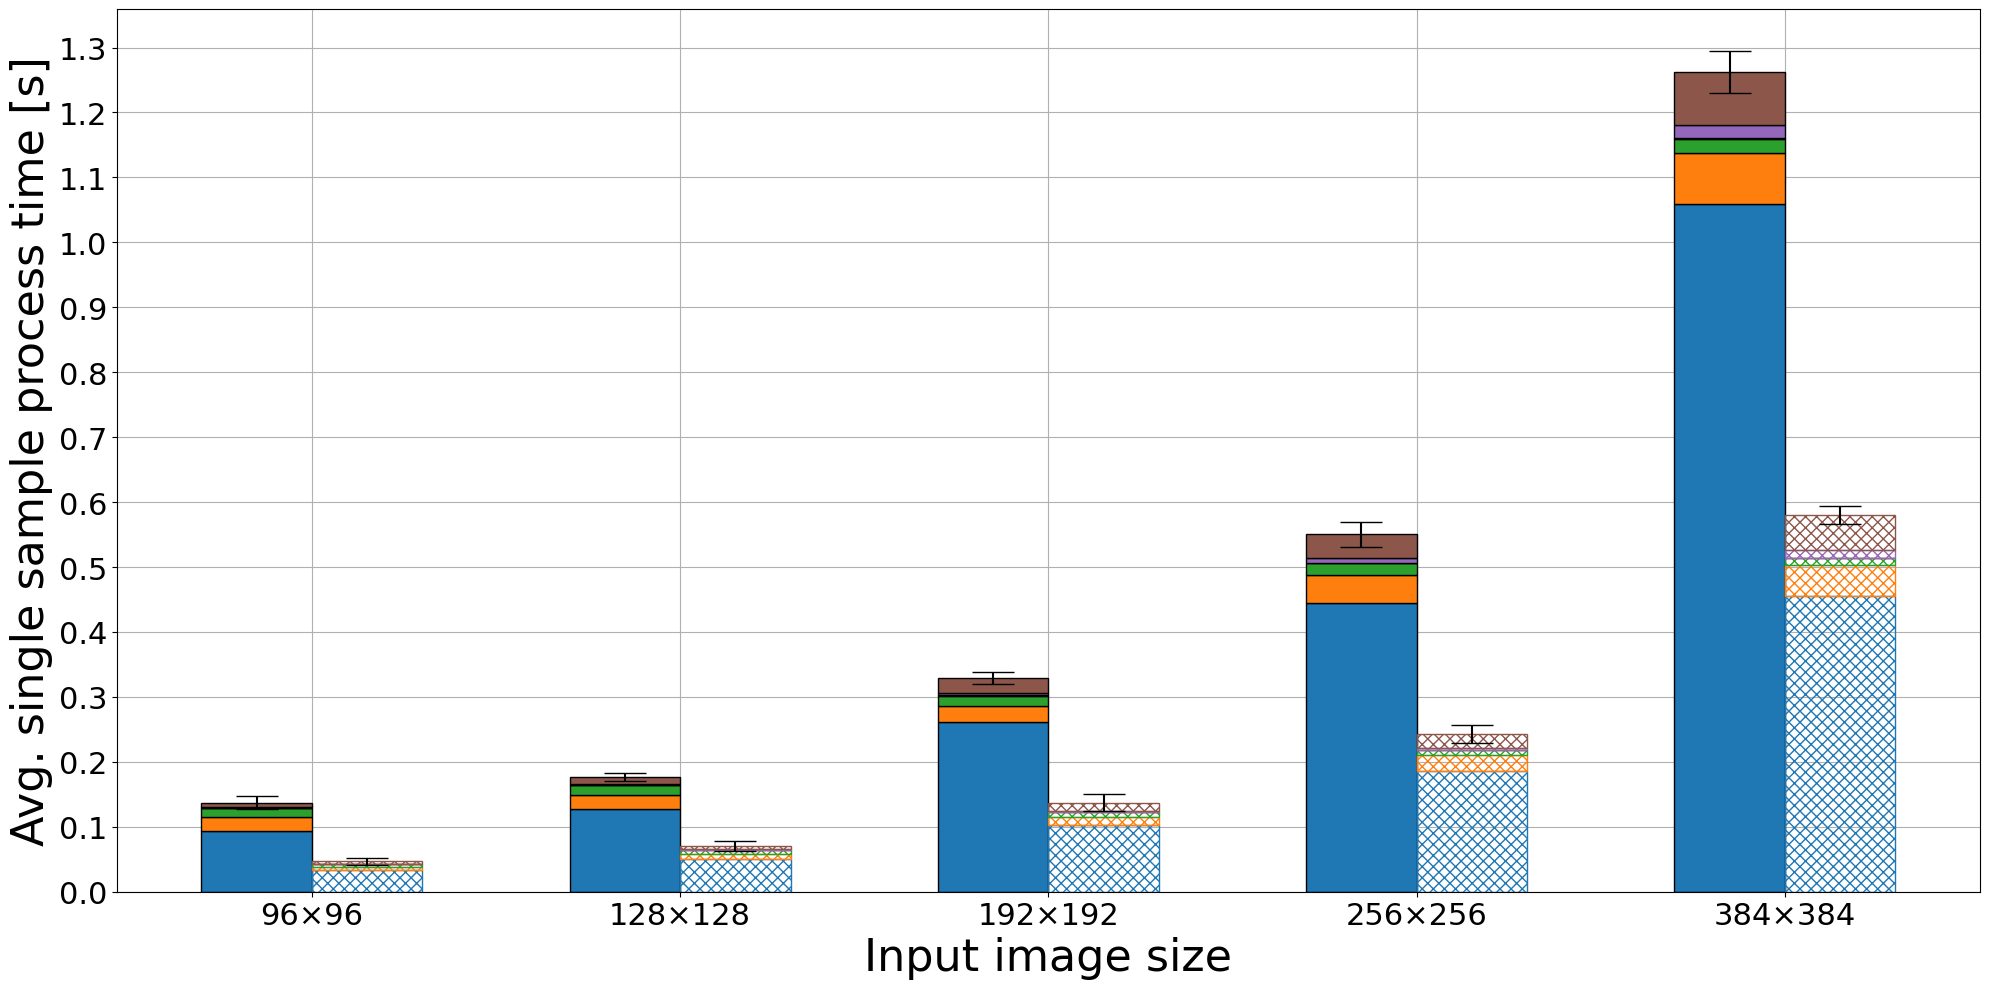

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(20, 10))

X = ["96×96", "128×128", "192×192", "256×256", "384×384"]

X_axis = np.arange(len(X))
Y_axis = np.round(np.arange(0, 1.4, 0.1), 1)

width = 0.3

ax.bar(X_axis - width / 2, rpi_4B_inference, width, label="Inference", edgecolor="black")
bottom = np.array(rpi_4B_inference)
ax.bar(X_axis - width / 2, rpi_4B_preprocessing, width, label="Preprocessing", edgecolor="black", bottom=bottom)
bottom += np.array(rpi_4B_preprocessing)
ax.bar(X_axis - width / 2, rpi_4B_sun_mask, width, label="Sun Mask", edgecolor="black", bottom=bottom)
bottom += np.array(rpi_4B_sun_mask)
ax.bar(X_axis - width / 2, rpi_4B_irradiance_channel, width, label="Irradiance Channel", edgecolor="black", bottom=bottom)
bottom += np.array(rpi_4B_irradiance_channel)
ax.bar(X_axis - width / 2, rpi_4B_cloud_channel, width, label="Cloud Channel", edgecolor="black", bottom=bottom)
bottom += np.array(rpi_4B_cloud_channel)
ax.bar(X_axis - width / 2, rpi_4B_optical_flow, width, label="Optical Flow", edgecolor="black", bottom=bottom)

yerr = (
    np.array(rpi_4B_inference_std)
    + np.array(rpi_4B_preprocessing_std)
    + np.array(rpi_4B_sun_mask_std)
    + np.array(rpi_4B_irradiance_channel_std)
    + np.array(rpi_4B_cloud_channel_std)
    + np.array(rpi_4B_optical_flow_std)
)
y = bottom + np.array(rpi_4B_optical_flow)
ax.errorbar(X_axis - width / 2, y, yerr=yerr, fmt="none", ecolor="black", capsize=15)

ax.bar(X_axis + width / 2, rpi_5_inference, width, label="Inference", hatch="xxx", fill=False, edgecolor="tab:blue")
bottom = np.array(rpi_5_inference)
ax.bar(
    X_axis + width / 2,
    rpi_5_preprocessing,
    width,
    label="Preprocessing",
    hatch="xxx",
    fill=False,
    edgecolor="tab:orange",
    bottom=bottom,
)
bottom += np.array(rpi_5_preprocessing)
ax.bar(
    X_axis + width / 2, rpi_5_sun_mask, width, label="Sun Mask", hatch="xxx", fill=False, edgecolor="tab:green", bottom=bottom
)
bottom += np.array(rpi_5_sun_mask)
ax.bar(
    X_axis + width / 2,
    rpi_5_irradiance_channel,
    width,
    label="Irradiance Channel",
    hatch="xxx",
    fill=False,
    edgecolor="tab:red",
    bottom=bottom,
)
bottom += np.array(rpi_5_irradiance_channel)
ax.bar(
    X_axis + width / 2,
    rpi_5_cloud_channel,
    width,
    label="Cloud Channel",
    hatch="xxx",
    fill=False,
    edgecolor="tab:purple",
    bottom=bottom,
)
bottom += np.array(rpi_5_cloud_channel)
ax.bar(
    X_axis + width / 2,
    rpi_5_optical_flow,
    width,
    label="Optical Flow",
    hatch="xxx",
    fill=False,
    edgecolor="tab:brown",
    bottom=bottom,
)

yerr = (
    np.array(rpi_5_inference_std)
    + np.array(rpi_5_preprocessing_std)
    + np.array(rpi_5_sun_mask_std)
    + np.array(rpi_5_irradiance_channel_std)
    + np.array(rpi_5_cloud_channel_std)
    + np.array(rpi_5_optical_flow_std)
)
y = bottom + np.array(rpi_5_optical_flow)
ax.errorbar(X_axis + width / 2, y, yerr=yerr, fmt="none", ecolor="black", capsize=15)

ax.set_xticks(X_axis, X, fontsize=22)
ax.set_yticks(Y_axis, Y_axis, fontsize=22)
ax.set_xlabel("Input image size", fontsize=32)
ax.set_ylabel("Avg. single sample process time [s]", fontsize=32)
ax.grid(True)
ax.set_axisbelow(True)
# plt.legend(fontsize=26)
plt.tight_layout()
plt.show()